In [ ]:
# ========================================================
# PROJECT: CreditLens 2.0
# GOAL: Predictive Insolvency Model (Operational vs Massified)
# STRATEGY: Bridging Phone to PC via Colab
# ========================================================

import pandas as pd
import numpy as np

# Feature definitions (100% English)
FEATURES = [
    'store_foot_traffic',
    'managerial_revenue',
    'inventory_liquidity_ratio',
    'staff_sentiment_score',
    'reinvestment_index',
    'debt_mix_ratio',
    'supplier_credit_terms',
    'b2b_client_concentration',
    'operating_leverage_delta'
]

TARGET = 'insolvency_status'

def initialize_project():
    print("--- CreditLens 2.0 Project Initialized ---")
    print(f"Target Variable: {TARGET}")
    print(f"Active Features: {len(FEATURES)}")
    for i, feature in enumerate(FEATURES, 1):
        print(f"{i}. {feature}")

initialize_project()

--- CreditLens 2.0 Project Initialized ---
Target Variable: insolvency_status
Active Features: 9
1. store_foot_traffic
2. managerial_revenue
3. inventory_liquidity_ratio
4. staff_sentiment_score
5. reinvestment_index
6. debt_mix_ratio
7. supplier_credit_terms
8. b2b_client_concentration
9. operating_leverage_delta


In [ ]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)
n_samples = 1000

# 1. Generating Predictors (Features)
data = {
    'store_foot_traffic': np.random.randint(1, 11, n_samples),
    'managerial_revenue': np.random.normal(50000, 15000, n_samples),
    'inventory_liquidity_ratio': np.random.uniform(0.1, 0.9, n_samples),
    'staff_sentiment_score': np.random.randint(1, 11, n_samples),
    'reinvestment_index': np.random.randint(1, 11, n_samples),
    'debt_mix_ratio': np.random.uniform(0, 1, n_samples), # Higher = more toxic debt
    'supplier_credit_terms': np.random.randint(0, 90, n_samples), # Days
    'b2b_client_concentration': np.random.uniform(0.1, 0.8, n_samples),
    'operating_leverage_delta': np.random.normal(0, 0.2, n_samples)
}

df = pd.DataFrame(data)

# 2. Creating the "Insolvency Logic" (The Hidden Rule)
# We define a Risk Score where higher values increase the chance of insolvency
risk_score = (
    (10 - df['store_foot_traffic']) * 0.15 +
    (10 - df['staff_sentiment_score']) * 0.10 +
    (df['debt_mix_ratio'] * 0.25) +
    ((90 - df['supplier_credit_terms']) / 90) * 0.20 +
    (df['b2b_client_concentration'] * 0.15) +
    (df['operating_leverage_delta'] * 0.15)
)

# If risk_score > threshold, the company is likely to become insolvent
# Adding some noise to simulate real-world unpredictability
threshold = risk_score.quantile(0.75) # 25% of companies will be insolvent
df['insolvency_status'] = (risk_score > threshold).astype(int)

print("Dataset generated successfully!")
print(f"Total Companies: {len(df)}")
print(f"Insolvent cases (Target = 1): {df['insolvency_status'].sum()}")
df.head()

Dataset generated successfully!
Total Companies: 1000
Insolvent cases (Target = 1): 250


,store_foot_traffic,managerial_revenue,inventory_liquidity_ratio,staff_sentiment_score,reinvestment_index,debt_mix_ratio,supplier_credit_terms,b2b_client_concentration,operating_leverage_delta,insolvency_status
0,7,63017.735550,0.178050,10,10,0.752114,35,0.516694,0.254213,0
1,4,35952.289738,0.789590,7,9,0.512875,31,0.477436,-0.196012,0
2,8,36867.124598,0.468130,7,3,0.320855,27,0.778170,-0.323560,0
3,5,53069.153143,0.699427,6,10,0.596050,76,0.438949,0.076156,0
4,7,40960.282920,0.332470,4,6,0.995734,0,0.144521,-0.163482,0


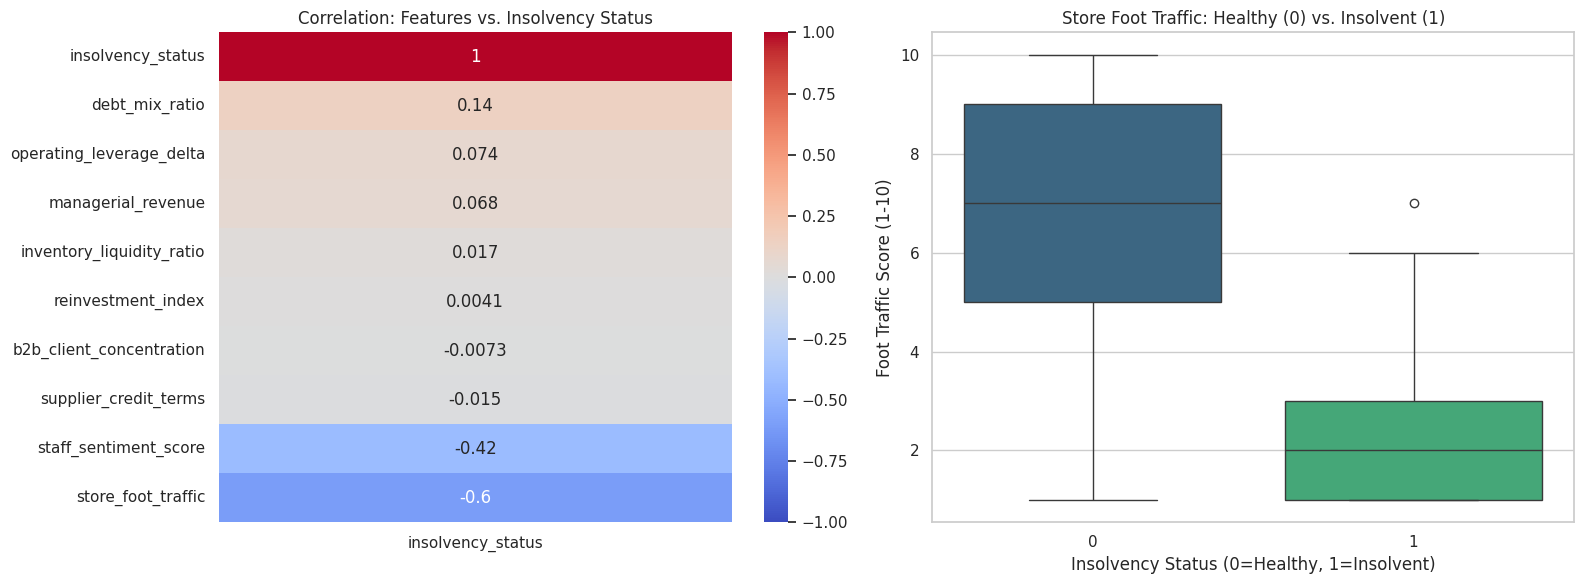

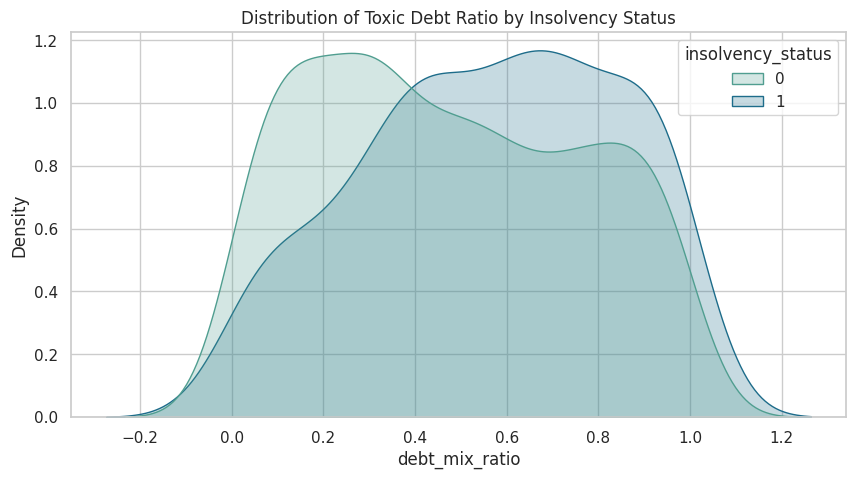

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# 1. Correlation Heatmap (Refined)
plt.subplot(1, 2, 1)
correlation_matrix = df.corr()
# We look only at the correlation with the Target
sns.heatmap(correlation_matrix[[TARGET]].sort_values(by=TARGET, ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation: Features vs. Insolvency Status")

# 2. Boxplot: Store Foot Traffic vs. Insolvency (Corrected for v0.14+)
plt.subplot(1, 2, 2)
# Fix: Assigning x to hue and disabling the legend as requested by the warning
sns.boxplot(x=TARGET, y='store_foot_traffic', data=df, hue=TARGET, palette='viridis', legend=False)
plt.title("Store Foot Traffic: Healthy (0) vs. Insolvent (1)")
plt.xlabel("Insolvency Status (0=Healthy, 1=Insolvent)")
plt.ylabel("Foot Traffic Score (1-10)")

plt.tight_layout()
plt.show()

# 3. Distribution Analysis (Already using hue correctly)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='debt_mix_ratio', hue=TARGET, fill=True, common_norm=False, palette='crest')
plt.title("Distribution of Toxic Debt Ratio by Insolvency Status")
plt.show()

--- MODEL PERFORMANCE REPORT ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       149
           1       0.90      0.88      0.89        51

    accuracy                           0.94       200
   macro avg       0.93      0.92      0.93       200
weighted avg       0.94      0.94      0.94       200



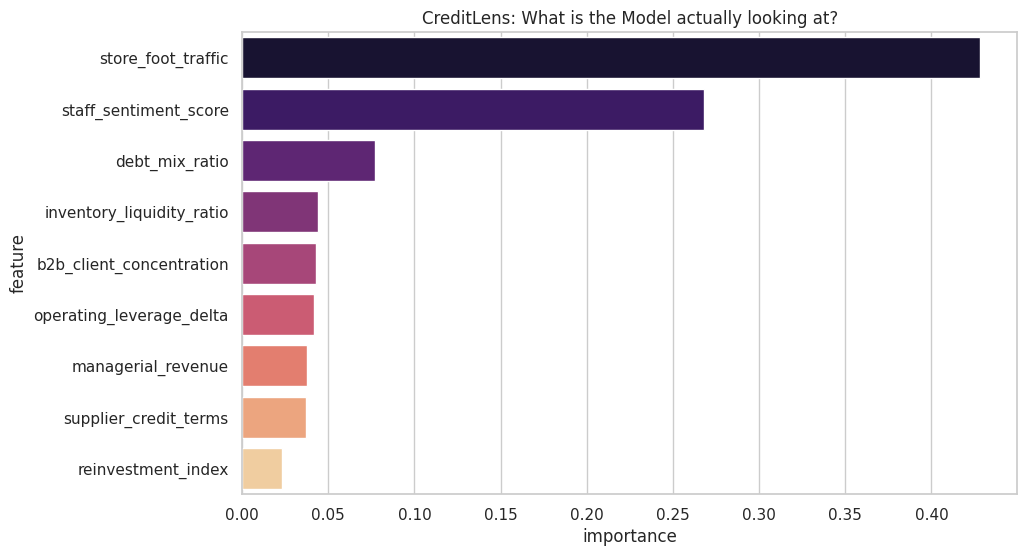

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Preparing the data
# X = Features (what we observe), y = Target (what we want to predict)
X = df[FEATURES]
y = df[TARGET]

# Splitting: 80% for training, 20% for testing our accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Training the "CreditLens" Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Making Predictions
y_pred = model.predict(X_test)

# 4. Evaluation
print("--- MODEL PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred))

# 5. Visualizing Feature Importance (The "Why")
importances = pd.DataFrame({'feature': FEATURES, 'importance': model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances, hue='feature', palette='magma', legend=False)
plt.title("CreditLens: What is the Model actually looking at?")
plt.show()

--- BUSINESS IMPACT ANALYSIS ---
Companies rejected by the Bank but actually healthy: 663
Estimated monthly profit lost by the Bank: R$ 663,000.00


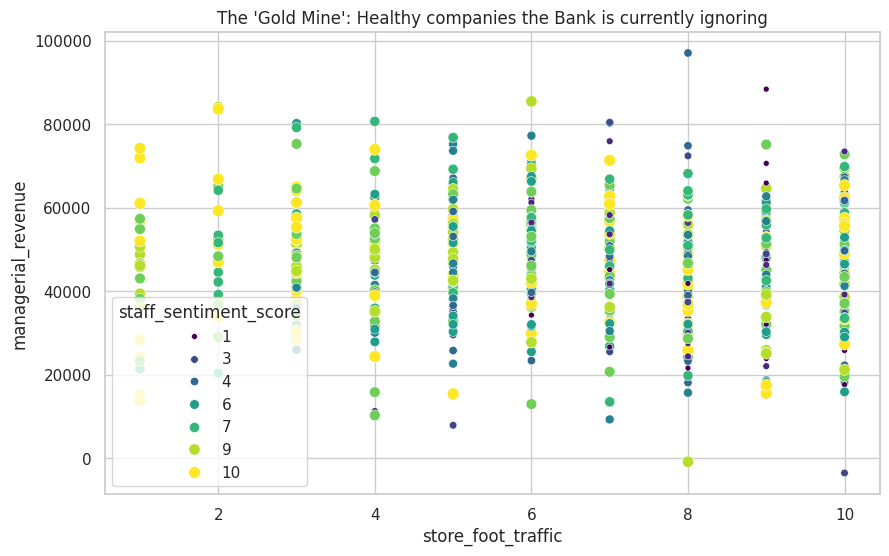

In [11]:
# 1. Simulating the "Bank's Rigid Model"
# The bank only looks at official revenue and debt ratio, ignoring your 'vibe' variables
df['bank_decision'] = np.where((df['managerial_revenue'] > 60000) & (df['debt_mix_ratio'] < 0.4), 0, 1)

# 2. Identifying "False Negatives" (The bank rejected, but they are actually healthy)
# We look for companies where bank_decision is 1 (Reject) but insolvency_status is 0 (Actually Healthy)
saved_by_marco = df[(df['bank_decision'] == 1) & (df['insolvency_status'] == 0)]

# 3. Calculating the "Opportunity Cost" (Loss of Profit)
# Let's assume an average credit limit of 50k and a 2% spread monthly
estimated_loss = len(saved_by_marco) * 50000 * 0.02

print(f"--- BUSINESS IMPACT ANALYSIS ---")
print(f"Companies rejected by the Bank but actually healthy: {len(saved_by_marco)}")
print(f"Estimated monthly profit lost by the Bank: R$ {estimated_loss:,.2f}")

# Visualizing the 'Saved' companies profile
plt.figure(figsize=(10, 6))
sns.scatterplot(data=saved_by_marco, x='store_foot_traffic', y='managerial_revenue',
                size='staff_sentiment_score', hue='staff_sentiment_score', palette='viridis')
plt.title("The 'Gold Mine': Healthy companies the Bank is currently ignoring")
plt.show()

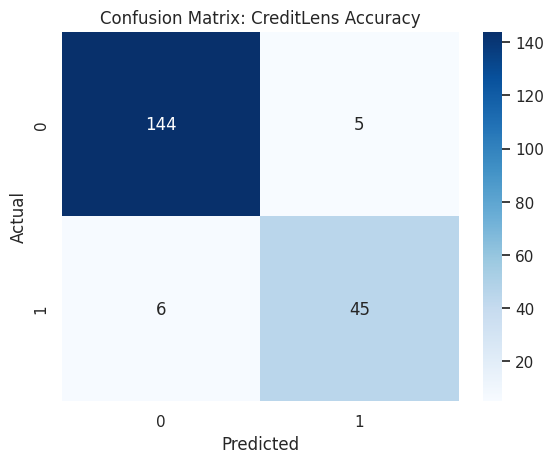

In [12]:
from sklearn.metrics import confusion_matrix

# Creating the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: CreditLens Accuracy')
plt.show()

In [13]:
import joblib

# Saving the trained model
model_path = '/content/drive/MyDrive/creditlens_model_v1.pkl'
joblib.dump(model, model_path)

# Saving the results to a CSV for your Portfolio
df.to_csv('/content/drive/MyDrive/creditlens_synthetic_data.csv', index=False)

print(f"Project saved! Model: {model_path}")

Project saved! Model: /content/drive/MyDrive/creditlens_model_v1.pkl
